In [3]:
from itertools import product
from fractions import Fraction

Obtenemos el espacio muestral para el experimento de lanzar dos dados

In [4]:
L= [i for i in range(1,7)]

Omega = set(product(L, repeat =  2))
Omega


{(1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 5),
 (5, 6),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5),
 (6, 6)}

Se crea un diccionario en donde se tiene como llave un par de valores  y como elemento, el resultado de la resta de este par: (i,j) -> i-j con la regla de que el resultado de esta resta tiene un valor mayor a 1

In [5]:
restaMayorUno = {(i,j): abs(i-j) for i,j in Omega if i-j > 1 or j-i >1}
restaMayorUno


{(3, 1): 2,
 (4, 6): 2,
 (5, 1): 4,
 (1, 6): 5,
 (2, 5): 3,
 (1, 3): 2,
 (6, 2): 4,
 (4, 2): 2,
 (3, 6): 3,
 (5, 3): 2,
 (2, 4): 2,
 (1, 5): 4,
 (6, 1): 5,
 (6, 4): 2,
 (4, 1): 3,
 (3, 5): 2,
 (5, 2): 3,
 (1, 4): 3,
 (2, 6): 4,
 (6, 3): 3}

Se crea un diccionario en donde se tiene como llave un par de valores y como elemento, el resultado de la suma de los valores tales que la suma de estos es un numero par

In [6]:
sumaPar = {(i,j): i+j for i,j in Omega if(i+j)%2 == 0}
sumaPar

{(3, 1): 4,
 (4, 6): 10,
 (5, 1): 6,
 (2, 2): 4,
 (1, 3): 4,
 (6, 2): 8,
 (4, 2): 6,
 (3, 3): 6,
 (5, 3): 8,
 (2, 4): 6,
 (1, 5): 6,
 (6, 4): 10,
 (3, 5): 8,
 (4, 4): 8,
 (5, 5): 10,
 (1, 1): 2,
 (2, 6): 8,
 (6, 6): 12}

Se agrupa en un diccionario los pares de Omega con su respectivo valor (diferencia que sea mayor a uno y la suma que sea par).

In [7]:
from collections import defaultdict
dsRestaMayorUno = defaultdict(set)

for i, j in restaMayorUno.items():
  dsRestaMayorUno[j].add(i)

dsRestaMayorUno


defaultdict(set,
            {2: {(1, 3),
              (2, 4),
              (3, 1),
              (3, 5),
              (4, 2),
              (4, 6),
              (5, 3),
              (6, 4)},
             4: {(1, 5), (2, 6), (5, 1), (6, 2)},
             5: {(1, 6), (6, 1)},
             3: {(1, 4), (2, 5), (3, 6), (4, 1), (5, 2), (6, 3)}})

In [8]:
dsSumaPar = defaultdict(set)
for i, j in sumaPar.items():
  dsSumaPar[j].add(i)
dsSumaPar

defaultdict(set,
            {4: {(1, 3), (2, 2), (3, 1)},
             10: {(4, 6), (5, 5), (6, 4)},
             6: {(1, 5), (2, 4), (3, 3), (4, 2), (5, 1)},
             8: {(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)},
             2: {(1, 1)},
             12: {(6, 6)}})

Se crea la funcion de la variable aleatoria discreta con distribucion uniforme

In [9]:
def Probabilidad(espacioMuestral, evento):
  p= Fraction(len(evento), espacioMuestral)
  return p

Obtendremos la probabilidad de cada escenario, almacenaremos estas probabilidades en un diccionario

In [18]:
totalValores = 0
for i in range(0, len(dsRestaMayorUno)):
  valoresKey = list(dsRestaMayorUno.values())[i]
  totalValores += len(valoresKey)

ProbabilidadesRestaMayorUno = {K: Probabilidad(totalValores,A) for K, A in dsRestaMayorUno.items()}
ProbabilidadesRestaMayorUno


{2: Fraction(2, 5), 4: Fraction(1, 5), 5: Fraction(1, 10), 3: Fraction(3, 10)}

In [15]:
totalValores = 0
for i in range(0, len(dsSumaPar)):
  valoresKey = list(dsSumaPar.values())[i]
  totalValores += len(valoresKey)


ProbabilidadesSumaPar = {K: Probabilidad(totalValores,A) for K, A in dsSumaPar.items()}
ProbabilidadesSumaPar

{4: Fraction(1, 6),
 10: Fraction(1, 6),
 6: Fraction(5, 18),
 8: Fraction(5, 18),
 2: Fraction(1, 18),
 12: Fraction(1, 18)}

Comprobamos que se cumple:
   $$\sum_{k\in R_{X}}\mathbb{P}(X=k) = 1$$

In [ ]:
sum(ProbabilidadesRestaMayorUno.values())


Fraction(1, 1)

In [ ]:
sum(ProbabilidadesSumaPar.values())

Fraction(1, 1)

Graficamos su funcion de distribucion de cada ley de variable aleatoria


# V.A en donde la diferencia de las caras sea mayor a 1

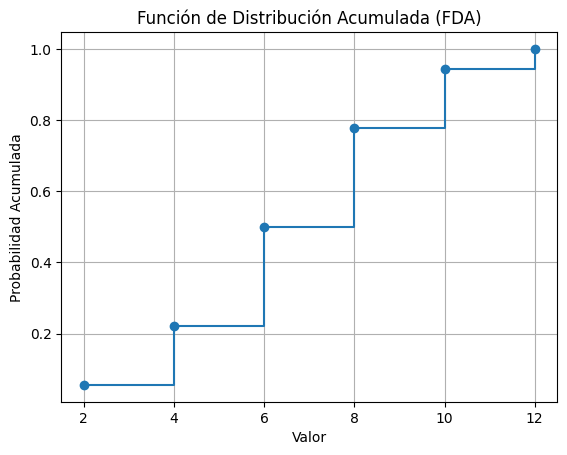

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from fractions import Fraction


probabilidades = {
    4: Fraction(1, 6),
    10: Fraction(1, 6),
    6: Fraction(5, 18),
    8: Fraction(5, 18),
    2: Fraction(1, 18),
    12: Fraction(1, 18)
}


valores = sorted(probabilidades.keys())
prob_list = [float(probabilidades[v]) for v in valores]
fda = np.cumsum(prob_list)


plt.step(valores, fda, where='post', marker='o')
plt.title('Función de Distribución Acumulada (FDA)')
plt.xlabel('Valor')
plt.ylabel('Probabilidad Acumulada')
plt.grid(True)
plt.show()



# V.A en donde la suma de las caras es un numero par

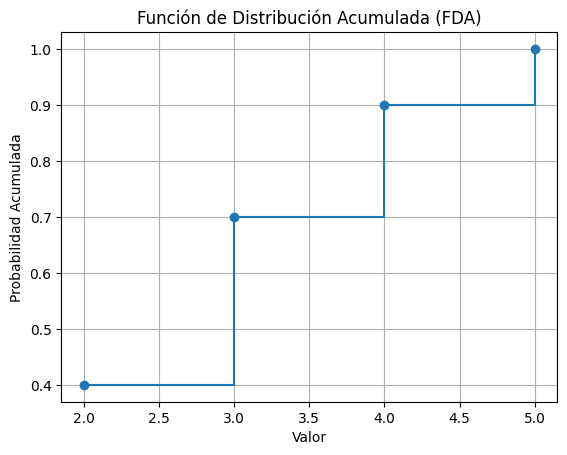

In [2]:

probabilidades = {
2: Fraction(2, 5),
3: Fraction(3, 10),
4: Fraction(1, 5),
5: Fraction(1, 10),
}


valores = sorted(probabilidades.keys())
prob_list = [float(probabilidades[v]) for v in valores]
fda = np.cumsum(prob_list)


plt.step(valores, fda, where='post', marker='o')
plt.title('Función de Distribución Acumulada (FDA)')
plt.xlabel('Valor')
plt.ylabel('Probabilidad Acumulada')
plt.grid(True)
plt.show()